In [1]:
# Step 1: Load the Dataset
# ```python
from sklearn.datasets import load_iris
import pandas as pd

# Load the iris dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name='species')


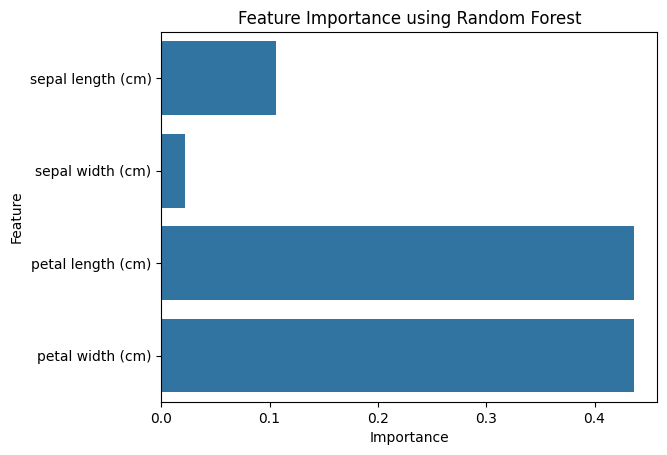

In [2]:
# Step 2: Feature Importance using Tree-based Methods
# ```python
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Train a Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# Get feature importances
feature_importances = model.feature_importances_

# Plot feature importances
sns.barplot(x=feature_importances, y=iris.feature_names)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance using Random Forest')
plt.show()


In [4]:
# Step 3: Feature Selection using Recursive Feature Elimination (RFE)
# ```python
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Create a logistic regression model
logreg = LogisticRegression(max_iter=1000)

# Use RFE to select the top 2 features
rfe = RFE(logreg, n_features_to_select=3)
rfe.fit(X, y)

# Get the selected features
selected_features = [feature for feature, rank in zip(iris.feature_names, rfe.ranking_) if rank == 1]
print("Selected Features:", selected_features)


Selected Features: ['sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


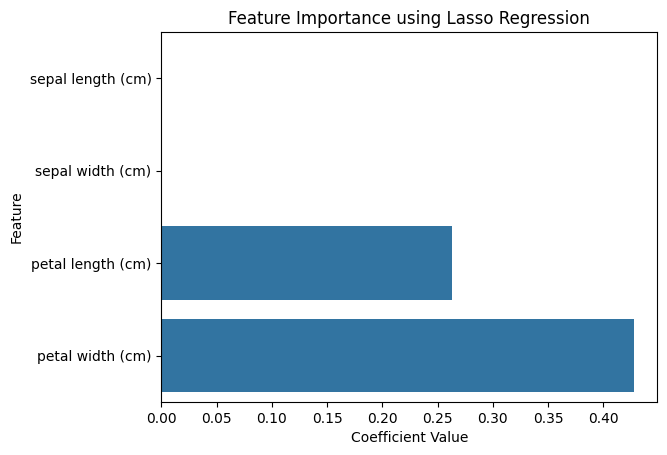

In [5]:
# Step 4: Feature Selection using Lasso Regression
# ```python
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
import numpy as np

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create a Lasso model
lasso = Lasso(alpha=0.1)

# Fit the model
lasso.fit(X_scaled, y)

# Get the coefficients
lasso_coefficients = lasso.coef_

# Plot the coefficients
sns.barplot(x=lasso_coefficients, y=iris.feature_names)
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Feature Importance using Lasso Regression')
plt.show()
